# Medical_Insurance_Cost_Prediction

In [2]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, KFold, cross_validate
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error
)

# Reproducibility
RANDOM_STATE = 42

# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:.3f}")

print("All dependencies imported successfully.")


All dependencies imported successfully.


##Dataset

For project I am using the commonly used Kaggle medical insurance dataset (`insurance.csv`).

#Columns present:

- `age`
- `sex`
- `bmi`
- `children`
- `smoker`
- `region`
- `charges`

The target variable is `charges`, a continuous numerical value, so this is a **regression** problem.

##  Load the dataset


In [3]:
import pandas as pd

insurance_dataset = pd.read_csv('/content/insurance.csv')

print("Dataset loaded successfully!")
print("Shape:", insurance_dataset.shape)

FileNotFoundError: [Errno 2] No such file or directory: '/content/insurance.csv'

In [3]:
insurance_dataset.head(10)

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.924
1,18,male,33.770,1,no,southeast,1725.552
2,28,male,33.000,3,no,southeast,4449.462
3,33,male,22.705,0,no,northwest,21984.471
4,32,male,28.880,0,no,northwest,3866.855
5,31,female,25.740,0,no,southeast,3756.622
6,46,female,33.440,1,no,southeast,8240.590
7,37,female,27.740,3,no,northwest,7281.506
8,37,male,29.830,2,no,northeast,6406.411
9,60,female,25.840,0,no,northwest,28923.137


In [4]:
insurance_dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [5]:
insurance_dataset.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
age,1338.000,NaN,NaN,NaN,39.207,14.050,18.000,27.000,39.000,51.000,64.000
sex,1338,2,male,676,NaN,NaN,NaN,NaN,NaN,NaN,NaN
bmi,1338.000,NaN,NaN,NaN,30.663,6.098,15.960,26.296,30.400,34.694,53.130
children,1338.000,NaN,NaN,NaN,1.095,1.205,0.000,0.000,1.000,2.000,5.000
smoker,1338,2,no,1064,NaN,NaN,NaN,NaN,NaN,NaN,NaN
region,1338,4,southeast,364,NaN,NaN,NaN,NaN,NaN,NaN,NaN
charges,1338.000,NaN,NaN,NaN,13270.422,12110.011,1121.874,4740.287,9382.033,16639.913,63770.428


##  Data quality checks

Before modelling, we check missing values, duplicates, and invalid numerical values.

In [6]:
print("Missing values:")
print(insurance_dataset.isnull().sum())

print("\nDuplicate rows:", insurance_dataset.duplicated().sum())

Missing values:
age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

Duplicate rows: 1


In [7]:
# Remove exact duplicate rows if any are present.
insurance_dataset = insurance_dataset.drop_duplicates().reset_index(drop=True)

numeric_columns = ["age", "bmi", "children", "charges"]

#INVALID VALUE_CHECKING
invalid_checks = {
    "age <= 0": (insurance_dataset["age"] <= 0).sum(),
    "bmi <= 0": (insurance_dataset["bmi"] <= 0).sum(),
    "children < 0": (insurance_dataset["children"] < 0).sum(),
    "charges < 0": (insurance_dataset["charges"] < 0).sum()
}

print("Invalid-value checks:")
for check, count in invalid_checks.items():
    print(f"{check}: {count}")

print("\nShape after duplicate handling:", insurance_dataset.shape)

Invalid-value checks:
age <= 0: 0
bmi <= 0: 0
children < 0: 0
charges < 0: 0

Shape after duplicate handling: (1337, 7)


##  Feature types

`age`, `bmi`, and `children` are numerical features. `sex`, `smoker`, and `region` are categorical features. `charges` is the target.

In [8]:
numerical_features = ["age", "bmi", "children"]
categorical_features = ["sex", "smoker", "region"]
target = "charges"

print("Numerical features:", numerical_features)
print("Categorical features:", categorical_features)
print("Target:", target)

Numerical features: ['age', 'bmi', 'children']
Categorical features: ['sex', 'smoker', 'region']
Target: charges


##  Exploratory Data Analysis — numerical distributions

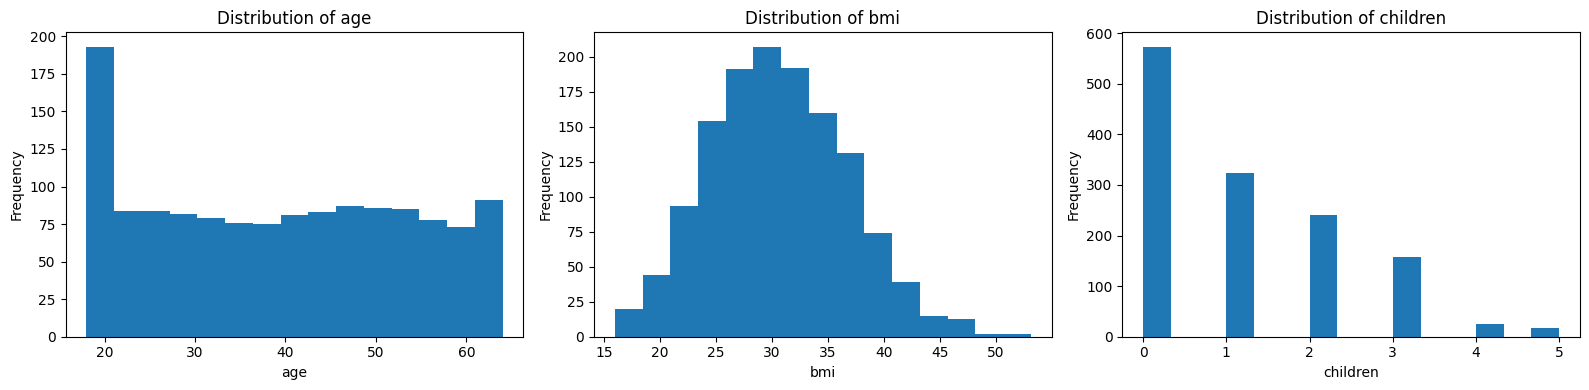

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, feature in zip(axes, numerical_features):
    ax.hist(insurance_dataset[feature], bins=15)
    ax.set_title(f"Distribution of {feature}")
    ax.set_xlabel(feature)
    ax.set_ylabel("Frequency")

plt.tight_layout()
plt.show()


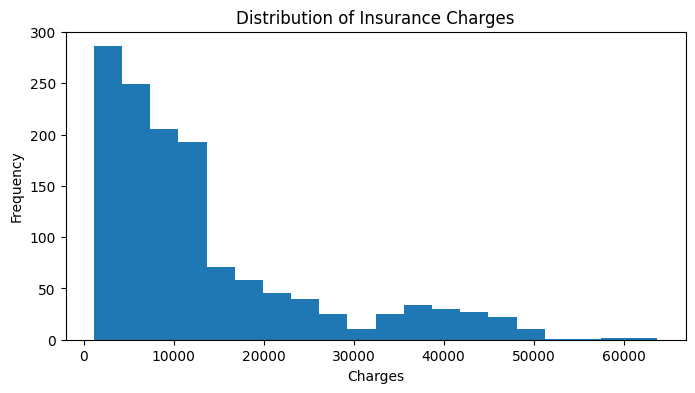

In [12]:
plt.figure(figsize=(8, 4))
plt.hist(insurance_dataset["charges"], bins=20)
plt.title("Distribution of Insurance Charges")
plt.xlabel("Charges")
plt.ylabel("Frequency")
plt.show()


### Distribution observation

The charge distribution is useful to inspect because very high-cost cases can make the target skewed. This matters when interpreting MAE and RMSE. A distribution being non-Gaussian does not automatically invalidate regression; the model and residual behaviour must be considered.

##  Categorical feature analysis

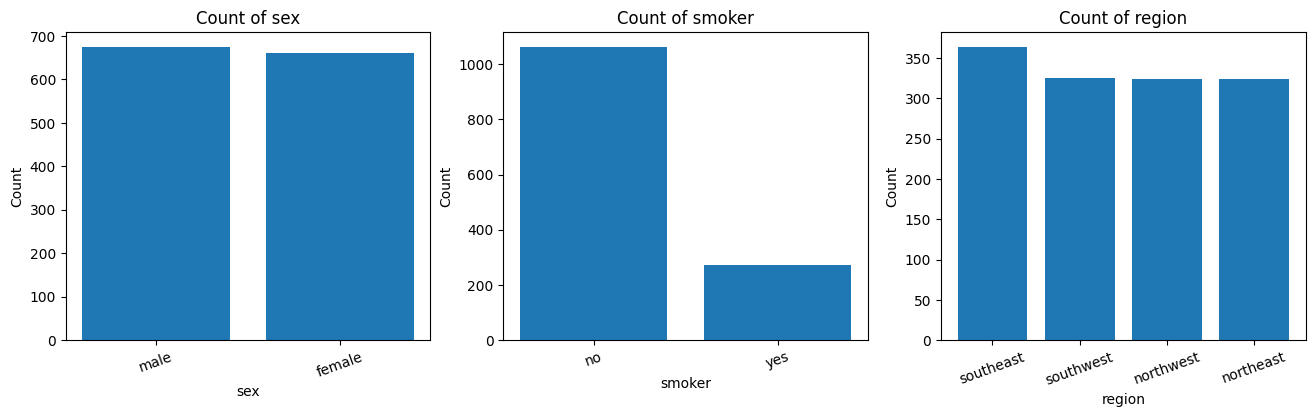

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, feature in zip(axes, categorical_features):
    counts = insurance_dataset[feature].value_counts()
    ax.bar(counts.index.astype(str), counts.values)
    ax.set_title(f"Count of {feature}")
    ax.set_xlabel(feature)
    ax.set_ylabel("Count")
    ax.tick_params(axis="x", rotation=20)


In [14]:
print("Sex:")
print(insurance_dataset["sex"].value_counts())

print("\nSmoker:")
print(insurance_dataset["smoker"].value_counts())

print("\nRegion:")
print(insurance_dataset["region"].value_counts())

Sex:
sex
male      675
female    662
Name: count, dtype: int64

Smoker:
smoker
no     1063
yes     274
Name: count, dtype: int64

Region:
region
southeast    364
southwest    325
northwest    324
northeast    324
Name: count, dtype: int64


##  Boxplots and possible outliers

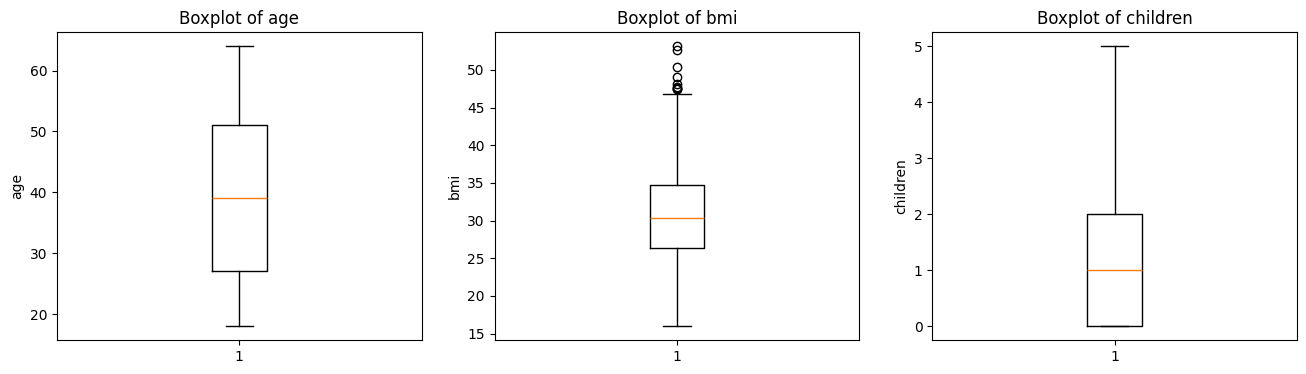

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, feature in zip(axes, numerical_features):
    ax.boxplot(insurance_dataset[feature].dropna())
    ax.set_title(f"Boxplot of {feature}")
    ax.set_ylabel(feature)


In [18]:
for feature in numerical_features:
    Q1 = insurance_dataset[feature].quantile(0.25)
    Q3 = insurance_dataset[feature].quantile(0.75)
    IQR = Q3 - Q1

    outliers = insurance_dataset[
        (insurance_dataset[feature] < Q1 - 1.5 * IQR) |
        (insurance_dataset[feature] > Q3 + 1.5 * IQR)
    ][feature]

    print(f"\n{feature} outliers:")
    print(outliers.tolist())


age outliers:
[]

bmi outliers:
[49.06, 48.07, 47.52, 47.41, 50.38, 47.6, 52.58, 47.74, 53.13]

children outliers:
[]


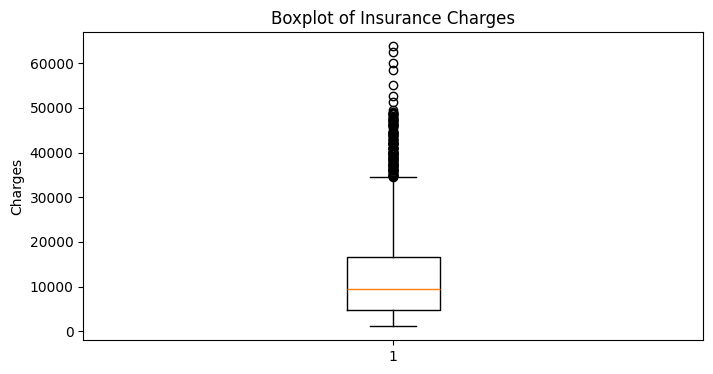

In [19]:
plt.figure(figsize=(8, 4))
plt.boxplot(insurance_dataset["charges"].dropna(), vert=True)
plt.title("Boxplot of Insurance Charges")
plt.ylabel("Charges")
plt.show()


**Important:** An observation being an outlier does not automatically mean it is an error. In insurance data, high charges may be genuine observations. We therefore do not remove observations simply because they are statistically unusual.

##  Feature relationships with charges

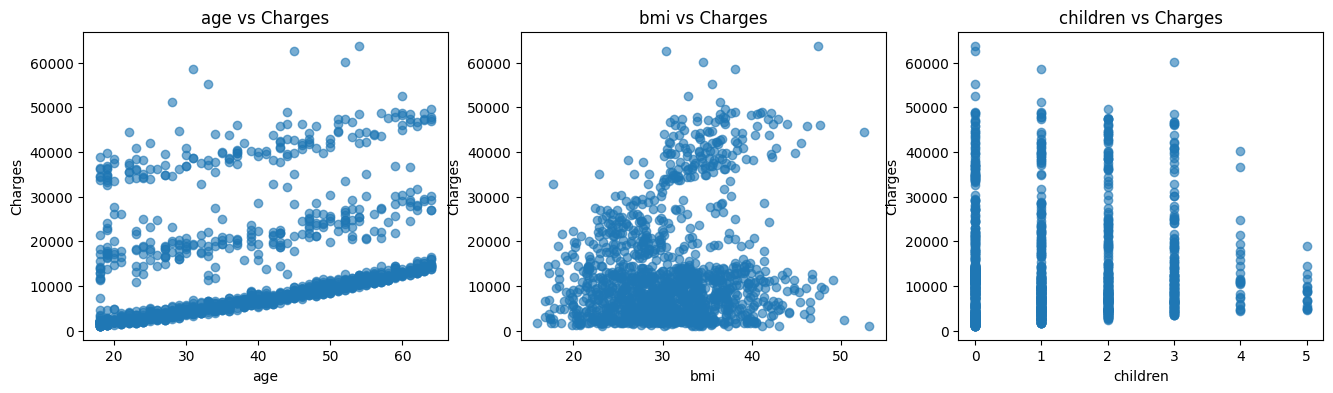

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, feature in zip(axes, numerical_features):
    ax.scatter(insurance_dataset[feature], insurance_dataset["charges"], alpha=0.6)
    ax.set_title(f"{feature} vs Charges")
    ax.set_xlabel(feature)
    ax.set_ylabel("Charges")


/tmp/ipykernel_1092/2080805622.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(groups, labels=labels)
/tmp/ipykernel_1092/2080805622.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(groups, labels=labels)
/tmp/ipykernel_1092/2080805622.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(groups, labels=labels)


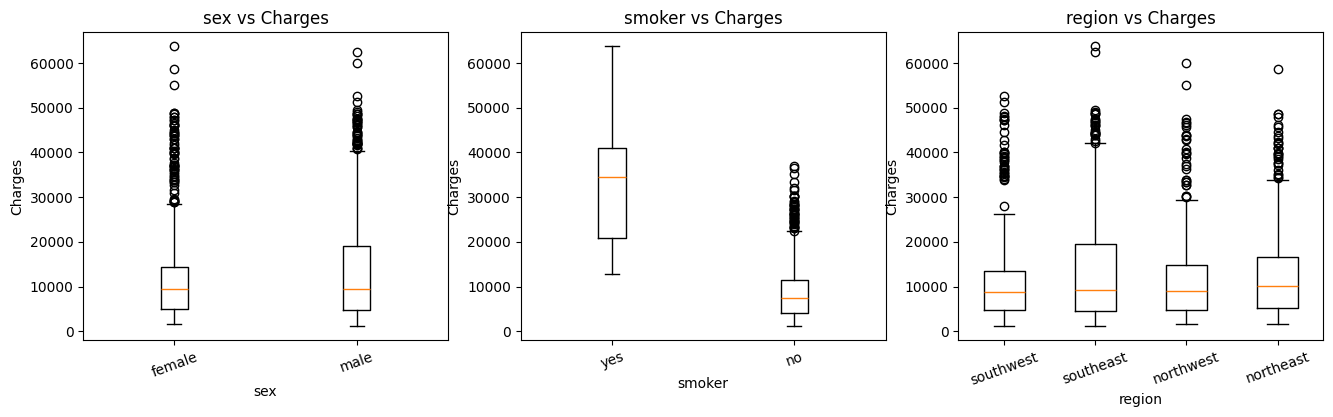

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, feature in zip(axes, categorical_features):
    groups = [insurance_dataset.loc[insurance_dataset[feature] == category, "charges"].dropna()
              for category in insurance_dataset[feature].unique()]
    labels = insurance_dataset[feature].unique()
    ax.boxplot(groups, labels=labels)
    ax.set_title(f"{feature} vs Charges")
    ax.set_xlabel(feature)
    ax.set_ylabel("Charges")
    ax.tick_params(axis="x", rotation=20)


##  Correlation analysis

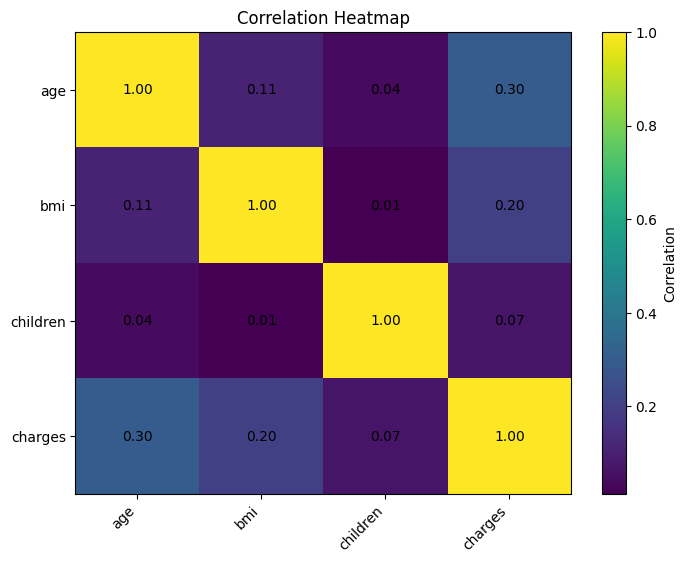

,charges
charges,1.000
age,0.298
bmi,0.198
children,0.067


In [21]:
correlation_matrix = insurance_dataset[numerical_features + ["charges"]].corr()

plt.figure(figsize=(8, 6))
plt.imshow(correlation_matrix, interpolation="nearest", aspect="auto")
plt.xticks(range(len(correlation_matrix.columns)), correlation_matrix.columns, rotation=45, ha="right")
plt.yticks(range(len(correlation_matrix.index)), correlation_matrix.index)
plt.colorbar(label="Correlation")
for i in range(len(correlation_matrix.index)):
    for j in range(len(correlation_matrix.columns)):
        plt.text(j, i, f"{correlation_matrix.iloc[i, j]:.2f}", ha="center", va="center")
plt.title("Correlation Heatmap")
plt.show()

correlation_matrix["charges"].sort_values(ascending=False)

### Correlation interpretation

Correlation measures association, not causation. A strong correlation does not prove that one variable causes changes in insurance charges.

For categorical variables, we will inspect group-wise charge differences rather than pretending that category labels have a natural numerical order.

In [22]:
for feature in categorical_features:
    print(f"\nAverage charges by {feature}:")
    print(
        insurance_dataset.groupby(feature)["charges"]
        .agg(["mean", "median", "count"])
        .sort_values("mean", ascending=False)
    )


Average charges by sex:
            mean   median  count
sex                             
male   13974.999 9377.905    675
female 12569.579 9412.962    662

Average charges by smoker:
            mean    median  count
smoker                           
yes    32050.232 34456.348    274
no      8440.660  7345.727   1063

Average charges by region:
               mean    median  count
region                              
southeast 14735.411  9294.132    364
northeast 13406.385 10057.652    324
northwest 12450.841  8976.977    324
southwest 12346.937  8798.593    325


##  Train-test split

We separate predictors and target before encoding. The test set is kept aside to provide an unbiased estimate of generalization.

In [24]:
X = insurance_dataset.drop(columns=[target])
y = insurance_dataset[target]

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.20,random_state=42)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (1069, 6)
X_test : (268, 6)
y_train: (1069,)
y_test : (268,)


##  Feature representation

The categorical variables need numerical representation before they can be used by the regression algorithms. We use one-hot encoding with `drop_first=True` to avoid redundant dummy columns.

In [25]:
X_train_encoded = pd.get_dummies(
    X_train,
    columns=categorical_features,
    drop_first=True,
    dtype=int
)

X_test_encoded = pd.get_dummies(
    X_test,
    columns=categorical_features,
    drop_first=True,
    dtype=int
)

# Ensure train and test have exactly the same feature columns.
X_test_encoded = X_test_encoded.reindex(
    columns=X_train_encoded.columns,
    fill_value=0
)

print("Encoded training shape:", X_train_encoded.shape)
print("Encoded test shape:", X_test_encoded.shape)
print("\nEncoded features:")
print(X_train_encoded.columns.tolist())

Encoded training shape: (1069, 8)
Encoded test shape: (268, 8)

Encoded features:
['age', 'bmi', 'children', 'sex_male', 'smoker_yes', 'region_northwest', 'region_southeast', 'region_southwest']


##  Cross-validation and hyperparameter selection

Before fitting the final three models, we select the Ridge regularization strength and KNN number of neighbors using **5-fold cross-validation on the training data only**.

The held-out test set is not used for this decision. This avoids using the test set to choose the final model and gives a cleaner estimate of generalization.

- Linear Regression is evaluated as the baseline.
- Ridge tests several `alpha` values.
- KNN tests several `k` values and uses `StandardScaler` inside the pipeline because it is distance-based.
- The primary selection metric is CV R²; CV MAE and CV RMSE are also reported.


In [27]:
# ==============================================================
# 5-fold cross-validation and hyperparameter selection
# ==============================================================
cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

scoring = {
    "R2": "r2",
    "MAE": "neg_mean_absolute_error",
    "RMSE": "neg_root_mean_squared_error"
}

# --------------------------------------------------------------
# Linear Regression: baseline CV performance
# --------------------------------------------------------------
linear_cv_scores = cross_validate(
    LinearRegression(),
    X_train_encoded,
    y_train,
    cv=cv,
    scoring=scoring,
    n_jobs=-1
)

linear_cv_metrics = {
    "CV R2": linear_cv_scores["test_R2"].mean(),
    "CV MAE": -linear_cv_scores["test_MAE"].mean(),
    "CV RMSE": -linear_cv_scores["test_RMSE"].mean()
}

# --------------------------------------------------------------
# Ridge: choose alpha using CV on training data only
# --------------------------------------------------------------
ridge_alpha_values = [0.01, 0.1, 1, 10, 100, 1000]
ridge_alpha_rows = []

for alpha in ridge_alpha_values:
    ridge_pipeline = Pipeline([
        ("scaler", StandardScaler()),
        ("ridge", Ridge(alpha=alpha))
    ])

    scores = cross_validate(
        ridge_pipeline,
        X_train_encoded,
        y_train,
        cv=cv,
        scoring=scoring,
        n_jobs=-1
    )

    ridge_alpha_rows.append({
        "alpha": alpha,
        "CV R2": scores["test_R2"].mean(),
        "CV MAE": -scores["test_MAE"].mean(),
        "CV RMSE": -scores["test_RMSE"].mean()
    })

ridge_alpha_results = pd.DataFrame(ridge_alpha_rows)
best_ridge_alpha = ridge_alpha_results.loc[
    ridge_alpha_results["CV R2"].idxmax(), "alpha"
]

# --------------------------------------------------------------
# KNN: choose k using CV on training data only
# --------------------------------------------------------------
knn_k_values = [3, 5, 7, 9, 11, 15, 21, 31]
knn_k_rows = []

for k in knn_k_values:
    knn_pipeline = Pipeline([
        ("scaler", StandardScaler()),
        ("knn", KNeighborsRegressor(n_neighbors=k))
    ])

    scores = cross_validate(
        knn_pipeline,
        X_train_encoded,
        y_train,
        cv=cv,
        scoring=scoring,
        n_jobs=-1
    )

    knn_k_rows.append({
        "k": k,
        "CV R2": scores["test_R2"].mean(),
        "CV MAE": -scores["test_MAE"].mean(),
        "CV RMSE": -scores["test_RMSE"].mean()
    })

knn_k_results = pd.DataFrame(knn_k_rows)
best_knn_k = int(knn_k_results.loc[
    knn_k_results["CV R2"].idxmax(), "k"
])

# --------------------------------------------------------------
# One model-level CV table using the selected configurations
# --------------------------------------------------------------
cv_results = pd.DataFrame([
    {
        "Model": "Linear Regression",
        "Selected Parameter": "None",
        **linear_cv_metrics
    },
    {
        "Model": "Ridge Regression",
        "Selected Parameter": f"alpha={best_ridge_alpha}",
        "CV R2": ridge_alpha_results.loc[
            ridge_alpha_results["alpha"] == best_ridge_alpha, "CV R2"
        ].iloc[0],
        "CV MAE": ridge_alpha_results.loc[
            ridge_alpha_results["alpha"] == best_ridge_alpha, "CV MAE"
        ].iloc[0],
        "CV RMSE": ridge_alpha_results.loc[
            ridge_alpha_results["alpha"] == best_ridge_alpha, "CV RMSE"
        ].iloc[0]
    },
    {
        "Model": "KNN Regression",
        "Selected Parameter": f"k={best_knn_k}",
        "CV R2": knn_k_results.loc[
            knn_k_results["k"] == best_knn_k, "CV R2"
        ].iloc[0],
        "CV MAE": knn_k_results.loc[
            knn_k_results["k"] == best_knn_k, "CV MAE"
        ].iloc[0],
        "CV RMSE": knn_k_results.loc[
            knn_k_results["k"] == best_knn_k, "CV RMSE"
        ].iloc[0]
    }
]).set_index("Model")

print(f"Selected Ridge alpha: {best_ridge_alpha}")
print(f"Selected KNN k: {best_knn_k}")
print("\nCross-validation results for selected configurations:")
display(cv_results.round(3))


Selected Ridge alpha: 1.0
Selected KNN k: 9

Cross-validation results for selected configurations:


,Selected Parameter,CV R2,CV MAE,CV RMSE
Model,,,,
Linear Regression,None,0.723,4221.963,6123.651
Ridge Regression,alpha=1.0,0.723,4223.195,6123.637
KNN Regression,k=9,0.767,3477.466,5603.963


##  Regression fundamentals

For Linear Regression, the model estimates a relationship between predictors and the continuous target.

The least-squares idea is to choose model parameters that make the sum of squared prediction errors as small as possible.

Residual:

`residual = actual value - predicted value`

We use the following evaluation measures:

- **MAE:** average absolute error
- **MSE:** average squared error
- **RMSE:** square root of MSE; gives extra weight to larger errors
- **R²:** proportion of target variation explained by the model

For this project, no single metric should be interpreted in isolation.

##  Evaluation helper

In [28]:
def evaluate_model(model, X_train, X_test, y_train, y_test):
    model.fit(X_train, y_train)

    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)

    metrics = {
        "Train R2": r2_score(y_train, train_pred),
        "Test R2": r2_score(y_test, test_pred),
        "Train MAE": mean_absolute_error(y_train, train_pred),
        "Test MAE": mean_absolute_error(y_test, test_pred),
        "Train RMSE": np.sqrt(mean_squared_error(y_train, train_pred)),
        "Test RMSE": np.sqrt(mean_squared_error(y_test, test_pred)),
    }

    return model, train_pred, test_pred, metrics

##  Model 1 — Linear Regression

Linear Regression is the natural baseline because the project is a continuous-value prediction problem and the course covers least squares and regression fitting.

In [29]:
linear_model = LinearRegression()

linear_model, lr_train_pred, lr_test_pred, lr_metrics = evaluate_model(
    linear_model,
    X_train_encoded,
    X_test_encoded,
    y_train,
    y_test
)

lr_metrics

{'Train R2': 0.7299057809339075,
 'Test R2': 0.8069287081198011,
 'Train MAE': 4181.90153777514,
 'Test MAE': 4177.045561036319,
 'Train RMSE': np.float64(6081.106881541277),
 'Test RMSE': np.float64(5956.342894363588)}

## Linear Regression — coefficient interpretation

Coefficients show the estimated change in predicted charges associated with a one-unit increase in a numerical feature, holding the other model features fixed. For dummy variables, coefficients are interpreted relative to the omitted reference category.

In [30]:
lr_coefficients = pd.Series(
    linear_model.coef_,
    index=X_train_encoded.columns
).sort_values(key=np.abs, ascending=False)

lr_coefficients

,0
smoker_yes,23077.765
region_southeast,-838.920
region_southwest,-659.140
children,533.010
region_northwest,-391.761
bmi,318.701
age,248.211
sex_male,-101.542


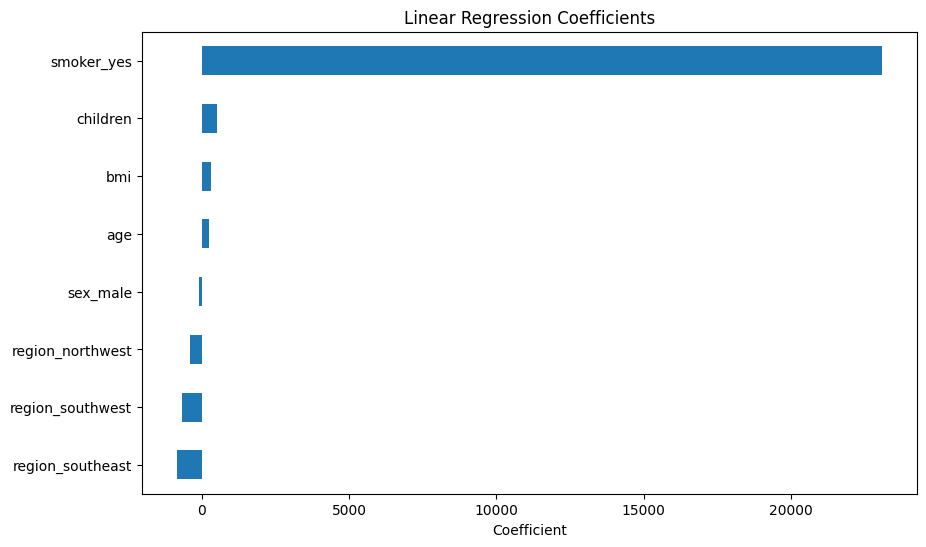

In [31]:
plt.figure(figsize=(10, 6))
lr_coefficients.sort_values().plot(kind="barh")
plt.title("Linear Regression Coefficients")
plt.xlabel("Coefficient")
plt.show()

##  Model 2 — Ridge Regression

Ridge Regression applies L2 regularization. The regularization penalty discourages excessively large coefficients and can improve generalization when predictors contain redundancy or when the model is sensitive to the training data.

In [32]:
# Ridge uses the alpha selected by 5-fold cross-validation on the training data.
ridge_model = Pipeline([
    ("scaler", StandardScaler()),
    ("ridge", Ridge(alpha=best_ridge_alpha))
])

ridge_model, ridge_train_pred, ridge_test_pred, ridge_metrics = evaluate_model(
    ridge_model,
    X_train_encoded,
    X_test_encoded,
    y_train,
    y_test
)

print(f"Selected Ridge alpha: {best_ridge_alpha}")
ridge_metrics


Selected Ridge alpha: 1.0


{'Train R2': 0.7299051033041128,
 'Test R2': 0.8067412087126403,
 'Train MAE': 4182.937191064992,
 'Test MAE': 4179.621622409952,
 'Train RMSE': np.float64(6081.114509873044),
 'Test RMSE': np.float64(5959.234416290865)}

### Why Ridge belongs in this project

Regularization is explicitly part of the concepts you described. Therefore Ridge provides a meaningful experiment: we can compare an ordinary least-squares baseline with a regularized linear model instead of adding an unrelated advanced algorithm.

##  Model 3 — KNN Regression

KNN Regression predicts a value using nearby observations. The method is distance-based, so the choice of representation and scale can influence its behaviour. Here it is included as a conceptually different regression model.

In [33]:
# KNN uses the K value selected by 5-fold cross-validation on the training data.
# KNN is distance-based, so StandardScaler is part of the pipeline.
knn_model = Pipeline([
    ("scaler", StandardScaler()),
    ("knn", KNeighborsRegressor(n_neighbors=best_knn_k))
])

knn_model, knn_train_pred, knn_test_pred, knn_metrics = evaluate_model(
    knn_model,
    X_train_encoded,
    X_test_encoded,
    y_train,
    y_test
)

print(f"Selected K for KNN: {best_knn_k}")
knn_metrics


Selected K for KNN: 9


{'Train R2': 0.8234451512248133,
 'Test R2': 0.8184603390735082,
 'Train MAE': 3085.5768097599002,
 'Test MAE': 3632.1662128776948,
 'Train RMSE': np.float64(4916.59932047805),
 'Test RMSE': np.float64(5775.726236518477)}

### Why scale KNN?

KNN is based on distances between observations. If one feature has a much larger numerical scale than another, it can dominate the distance calculation. Therefore, the KNN model is wrapped in a `Pipeline` with `StandardScaler` so that distance calculations are more balanced.

In [34]:
# Final test-set metrics for the three models after hyperparameters were
# selected using cross-validation on the training data only.
results = pd.DataFrame(
    [lr_metrics, ridge_metrics, knn_metrics],
    index=[
        "Linear Regression",
        "Ridge Regression",
        "KNN Regression"
    ]
)

# Add the cross-validation metrics used for model selection.
results = results.join(cv_results[["CV R2", "CV MAE", "CV RMSE"]])

print("Final model comparison:")
display(results.round(3))


Final model comparison:


,Train R2,Test R2,Train MAE,Test MAE,Train RMSE,Test RMSE,CV R2,CV MAE,CV RMSE
Linear Regression,0.730,0.807,4181.902,4177.046,6081.107,5956.343,0.723,4221.963,6123.651
Ridge Regression,0.730,0.807,4182.937,4179.622,6081.115,5959.234,0.723,4223.195,6123.637
KNN Regression,0.823,0.818,3085.577,3632.166,4916.599,5775.726,0.767,3477.466,5603.963


##  Combined model comparison

The table below combines the final test-set metrics with the cross-validation metrics from the selected configurations.


##  Compare final held-out test-set performance

The test set was not used to choose hyperparameters or the final model. It is used here only to compare the generalization performance of the already-selected model configurations.


In [35]:
test_comparison = results[
    ["Test R2", "Test MAE", "Test RMSE"]
].copy()

test_comparison.round(3)

,Test R2,Test MAE,Test RMSE
Linear Regression,0.807,4177.046,5956.343
Ridge Regression,0.807,4179.622,5959.234
KNN Regression,0.818,3632.166,5775.726


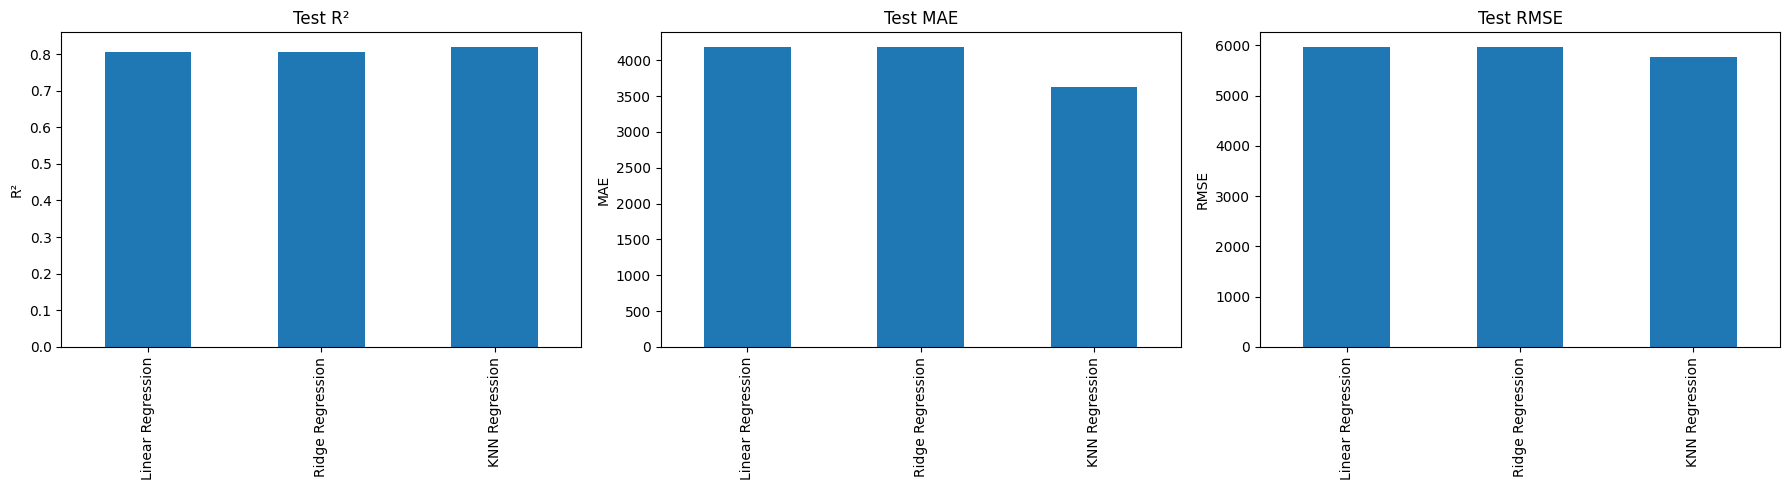

In [36]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

test_comparison["Test R2"].plot(kind="bar", ax=axes[0], title="Test R²")
axes[0].set_ylabel("R²")

test_comparison["Test MAE"].plot(kind="bar", ax=axes[1], title="Test MAE")
axes[1].set_ylabel("MAE")

test_comparison["Test RMSE"].plot(kind="bar", ax=axes[2], title="Test RMSE")
axes[2].set_ylabel("RMSE")

plt.tight_layout()
plt.show()

##  Train vs test performance — overfitting and underfitting

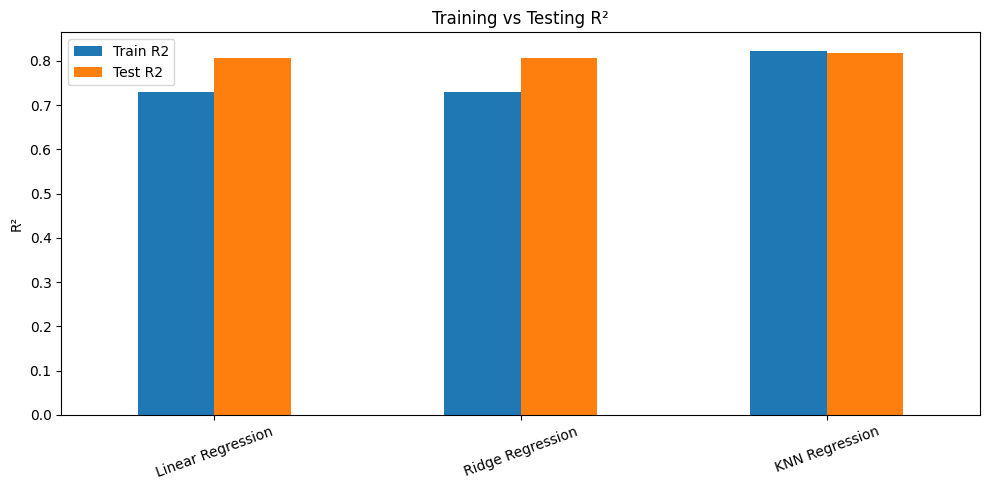

In [37]:
r2_train_test = results[["Train R2", "Test R2"]]

r2_train_test.plot(kind="bar", figsize=(10, 5))
plt.title("Training vs Testing R²")
plt.ylabel("R²")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

In [38]:
print("Training vs Testing R²:\n")

for model in results.index:
    print(model)
    print("Train R²:", round(results.loc[model, "Train R2"], 4))
    print("Test R² :", round(results.loc[model, "Test R2"], 4))
    print()

Training vs Testing R²:

Linear Regression
Train R²: 0.7299
Test R² : 0.8069

Ridge Regression
Train R²: 0.7299
Test R² : 0.8067

KNN Regression
Train R²: 0.8234
Test R² : 0.8185



In [32]:
performance_gap = pd.DataFrame({
    "R2 gap (Train - Test)": results["Train R2"] - results["Test R2"],
    "MAE gap (Test - Train)": results["Test MAE"] - results["Train MAE"],
    "RMSE gap (Test - Train)": results["Test RMSE"] - results["Train RMSE"]
})

performance_gap.round(3)

,R2 gap (Train - Test),MAE gap (Test - Train),RMSE gap (Test - Train)
Linear Regression,-0.077,-4.856,-124.764
Ridge Regression,-0.077,-3.316,-121.880
KNN Regression,0.005,546.589,859.127


### Bias-variance interpretation

A model that performs similarly on training and test data is generally showing better generalization.

A very large training-test gap can indicate high variance/overfitting.

If both training and testing performance are poor, the model may be too simple for the underlying relationship, which is consistent with underfitting/high bias.

These are diagnostic interpretations, not absolute mathematical proofs of bias or variance.

##  Cross-validation results review

The cross-validation and hyperparameter-selection process was completed before fitting the final models. The tables and plots below provide an additional view of those training-only validation results.


In [40]:
# Review the training-only CV results already calculated above.
print("Selected hyperparameters:")
print(f"Ridge alpha = {best_ridge_alpha}")
print(f"KNN k = {best_knn_k}")
display(cv_results.round(3))


Selected hyperparameters:
Ridge alpha = 1.0
KNN k = 9


,Selected Parameter,CV R2,CV MAE,CV RMSE
Model,,,,
Linear Regression,None,0.723,4221.963,6123.651
Ridge Regression,alpha=1.0,0.723,4223.195,6123.637
KNN Regression,k=9,0.767,3477.466,5603.963


##  Actual vs predicted values for the cross-validation-selected model

The final model is selected using cross-validation results from the training data. The held-out test set is then used only to report the final generalization performance.


In [41]:
# Select the final model using CV R², not test-set performance.
best_model_name = cv_results["CV R2"].idxmax()

prediction_map = {
    "Linear Regression": lr_test_pred,
    "Ridge Regression": ridge_test_pred,
    "KNN Regression": knn_test_pred
}

best_test_pred = prediction_map[best_model_name]

print("Final model selected using CV R²:", best_model_name)
print("CV R²:", cv_results.loc[best_model_name, "CV R2"])
print("Final held-out Test R²:", results.loc[best_model_name, "Test R2"])
print("Final held-out Test MAE:", results.loc[best_model_name, "Test MAE"])
print("Final held-out Test RMSE:", results.loc[best_model_name, "Test RMSE"])


Final model selected using CV R²: KNN Regression
CV R²: 0.7673834289422056
Final held-out Test R²: 0.8184603390735082
Final held-out Test MAE: 3632.1662128776948
Final held-out Test RMSE: 5775.726236518477


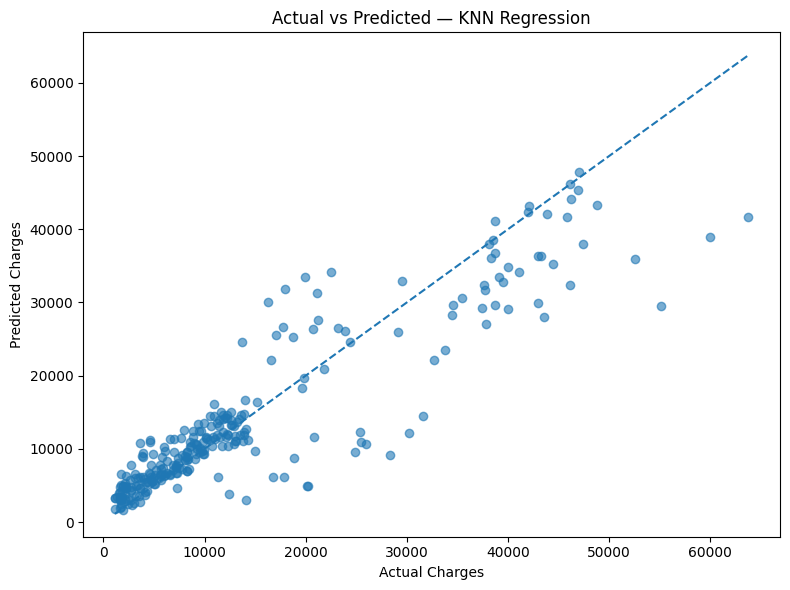

In [42]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, best_test_pred, alpha=0.6)
min_value = min(y_test.min(), best_test_pred.min())
max_value = max(y_test.max(), best_test_pred.max())
plt.plot([min_value, max_value], [min_value, max_value], linestyle="--")
plt.xlabel("Actual Charges")
plt.ylabel("Predicted Charges")
plt.title(f"Actual vs Predicted — {best_model_name}")
plt.tight_layout()
plt.show()


## Residual analysis

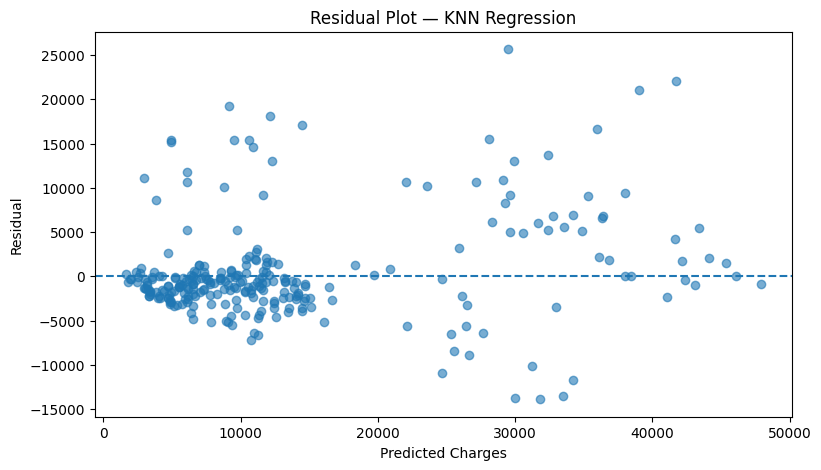

In [43]:
residuals = y_test - best_test_pred

plt.figure(figsize=(9, 5))
plt.scatter(best_test_pred, residuals, alpha=0.6)
plt.axhline(0, linestyle="--")
plt.xlabel("Predicted Charges")
plt.ylabel("Residual")
plt.title(f"Residual Plot — {best_model_name}")
plt.show()

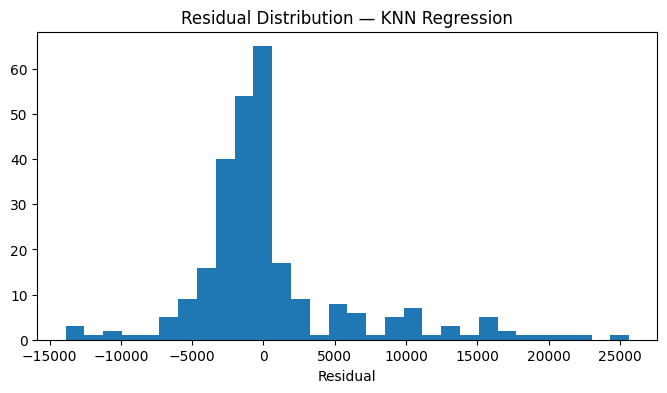

Mean residual: 463.43441131882247
Median residual: -693.1823283333335


In [44]:
plt.figure(figsize=(8, 4))
plt.hist(residuals, bins=30)
plt.title(f"Residual Distribution — {best_model_name}")
plt.xlabel("Residual")
plt.show()

print("Mean residual:", residuals.mean())
print("Median residual:", residuals.median())

### Residual interpretation

Ideally, residuals should be reasonably centered around zero without a strong systematic pattern. Clear structure in the residual plot can indicate that the model is missing part of the relationship.

##  Feature-level insights

In [45]:
print("Average charges by smoker status:")
print(
    insurance_dataset.groupby("smoker")["charges"]
    .agg(["mean", "median", "count"])
    .sort_values("mean", ascending=False)
)

print("\nAverage charges by sex:")
print(
    insurance_dataset.groupby("sex")["charges"]
    .agg(["mean", "median", "count"])
)

print("\nAverage charges by region:")
print(
    insurance_dataset.groupby("region")["charges"]
    .agg(["mean", "median", "count"])
    .sort_values("mean", ascending=False)
)

Average charges by smoker status:
            mean    median  count
smoker                           
yes    32050.232 34456.348    274
no      8440.660  7345.727   1063

Average charges by sex:
            mean   median  count
sex                             
female 12569.579 9412.962    662
male   13974.999 9377.905    675

Average charges by region:
               mean    median  count
region                              
southeast 14735.411  9294.132    364
northeast 13406.385 10057.652    324
northwest 12450.841  8976.977    324
southwest 12346.937  8798.593    325


### Important interpretation

Group averages show differences in the dataset, but they should not be described as causal effects. For example, a higher average charge among smokers does not mean smoking is the only reason for the difference; other variables and interactions can also contribute.

##  Interpreting age, BMI and smoking status

The project should discuss these variables using both EDA and the trained model rather than relying on one statistic.

- **Age:** examine its relationship with charges and its regression coefficient.
- **BMI:** inspect its scatter relationship with charges and coefficient behaviour.
- **Smoker:** compare group-wise charges and the corresponding encoded model coefficient.
- **Children:** examine whether the relationship appears strong or weak.
- **Sex and region:** compare group distributions while remembering that encoded coefficients depend on the chosen reference categories.

##  KNN model interpretation

KNN does not produce coefficients like Linear Regression and does not build a decision tree. Its prediction is based on the target values of nearby training observations. Because KNN is distance-based, the project scales features before fitting it. The number of neighbors `k` is selected using 5-fold cross-validation on the training data.


##  Hyperparameter validation experiments

The following plots show how Ridge `alpha` and KNN `k` affected cross-validation performance. These experiments were performed using training data only.


In [46]:
# Display the final comparison again after the selected models were evaluated.
display(results.round(3))


,Train R2,Test R2,Train MAE,Test MAE,Train RMSE,Test RMSE,CV R2,CV MAE,CV RMSE
Linear Regression,0.730,0.807,4181.902,4177.046,6081.107,5956.343,0.723,4221.963,6123.651
Ridge Regression,0.730,0.807,4182.937,4179.622,6081.115,5959.234,0.723,4223.195,6123.637
KNN Regression,0.823,0.818,3085.577,3632.166,4916.599,5775.726,0.767,3477.466,5603.963


Ridge alpha cross-validation results:


,alpha,CV R2,CV MAE,CV RMSE
0,0.010,0.723,4221.976,6123.651
1,0.100,0.723,4222.086,6123.649
2,1.000,0.723,4223.195,6123.637
3,10.000,0.723,4234.597,6124.562
4,100.000,0.715,4389.983,6214.982
5,1000.000,0.511,5941.482,8163.254


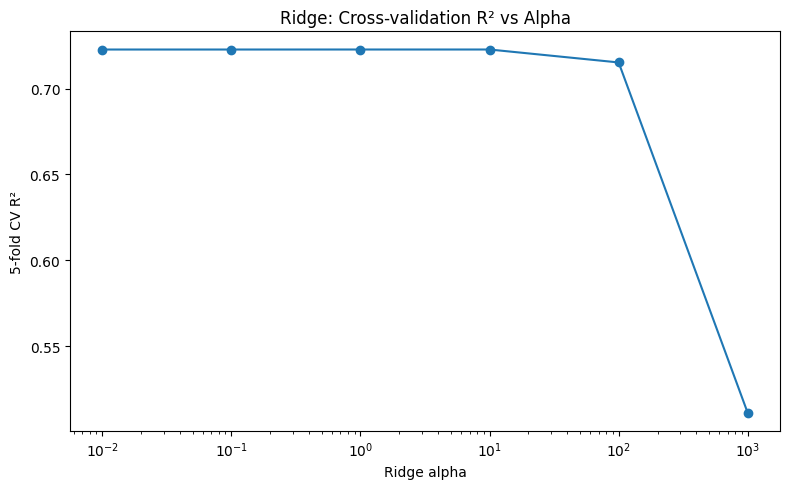

KNN k cross-validation results:


,k,CV R2,CV MAE,CV RMSE
0,3,0.755,3467.291,5734.814
1,5,0.766,3448.646,5609.812
2,7,0.763,3508.217,5643.187
3,9,0.767,3477.466,5603.963
4,11,0.762,3542.303,5669.151
5,15,0.753,3623.375,5785.580
6,21,0.736,3791.441,5987.045
7,31,0.703,4042.955,6353.748


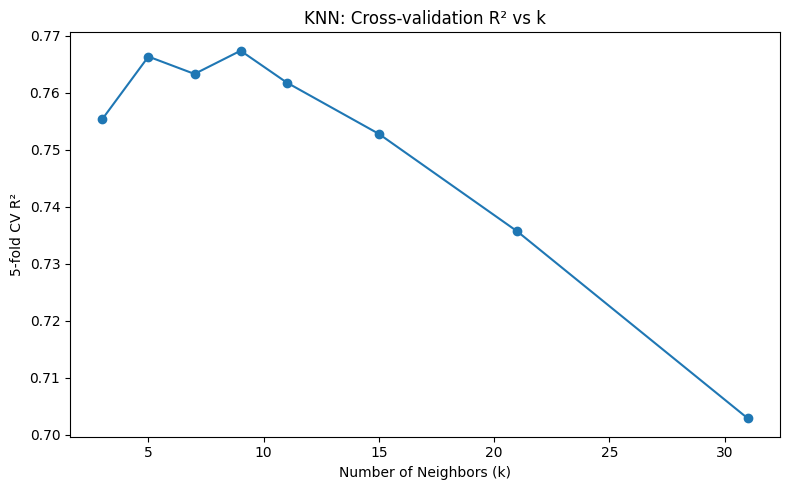

In [47]:
print("Ridge alpha cross-validation results:")
display(ridge_alpha_results.round(3))

plt.figure(figsize=(8, 5))
plt.plot(ridge_alpha_results["alpha"], ridge_alpha_results["CV R2"], marker="o")
plt.xscale("log")
plt.xlabel("Ridge alpha")
plt.ylabel("5-fold CV R²")
plt.title("Ridge: Cross-validation R² vs Alpha")
plt.tight_layout()
plt.show()

print("KNN k cross-validation results:")
display(knn_k_results.round(3))

plt.figure(figsize=(8, 5))
plt.plot(knn_k_results["k"], knn_k_results["CV R2"], marker="o")
plt.xlabel("Number of Neighbors (k)")
plt.ylabel("5-fold CV R²")
plt.title("KNN: Cross-validation R² vs k")
plt.tight_layout()
plt.show()


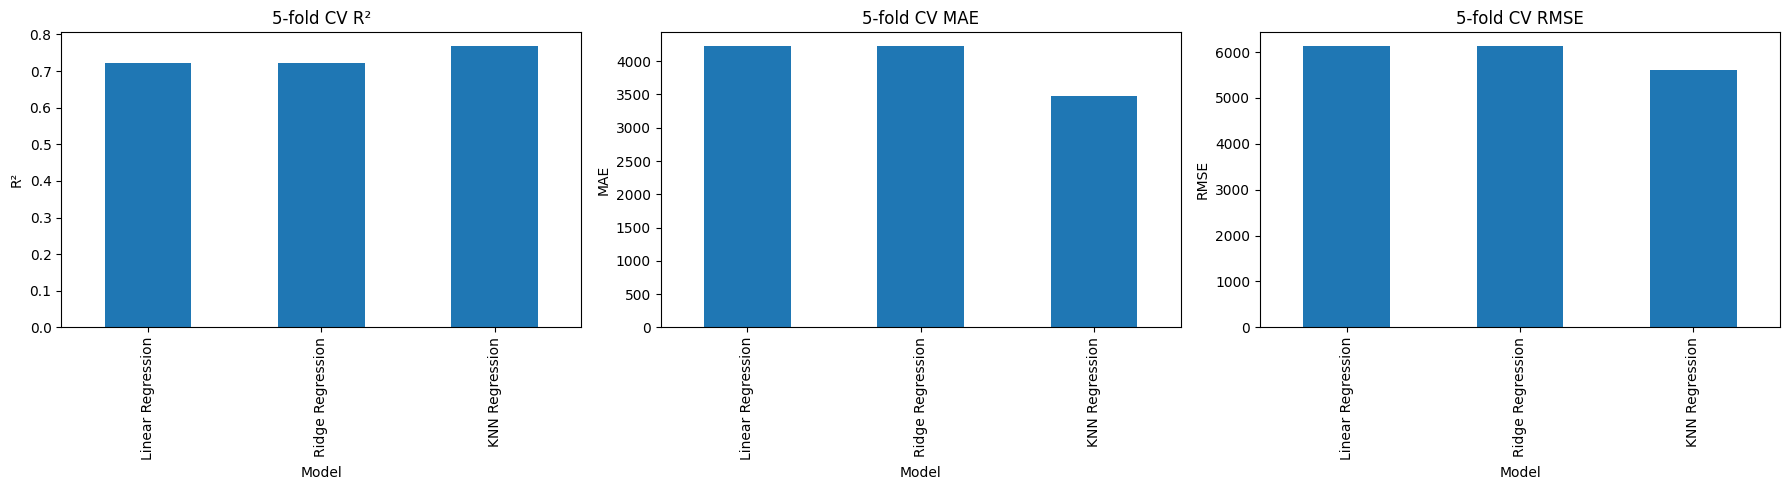

In [48]:
# Compare the selected model configurations using cross-validation.
cv_plot = cv_results[["CV R2", "CV MAE", "CV RMSE"]].copy()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
cv_plot["CV R2"].plot(kind="bar", ax=axes[0], title="5-fold CV R²")
axes[0].set_ylabel("R²")

cv_plot["CV MAE"].plot(kind="bar", ax=axes[1], title="5-fold CV MAE")
axes[1].set_ylabel("MAE")

cv_plot["CV RMSE"].plot(kind="bar", ax=axes[2], title="5-fold CV RMSE")
axes[2].set_ylabel("RMSE")

plt.tight_layout()
plt.show()


## Hyperparameter validation experiments

The detailed hyperparameter search was performed earlier, before fitting the final models. This section revisits those results for interpretation.


In [49]:
summary = results[[
    "CV R2", "Test R2",
    "CV MAE", "Test MAE",
    "CV RMSE", "Test RMSE"
]].round(3)

display(summary)

best_by_cv_r2 = cv_results["CV R2"].idxmax()
best_by_test_r2 = results["Test R2"].idxmax()
best_by_test_mae = results["Test MAE"].idxmin()
best_by_test_rmse = results["Test RMSE"].idxmin()

print("Final model selected using CV R²:", best_by_cv_r2)
print("Best by held-out Test R²:", best_by_test_r2)
print("Best by held-out Test MAE:", best_by_test_mae)
print("Best by held-out Test RMSE:", best_by_test_rmse)

if best_by_cv_r2 == best_by_test_r2:
    print("\nThe CV-selected model also has the highest Test R².")
else:
    print("\nThe CV-selected model differs from the Test-R² winner; this is useful evidence that model selection and final evaluation should be kept separate.")


,CV R2,Test R2,CV MAE,Test MAE,CV RMSE,Test RMSE
Linear Regression,0.723,0.807,4221.963,4177.046,6123.651,5956.343
Ridge Regression,0.723,0.807,4223.195,4179.622,6123.637,5959.234
KNN Regression,0.767,0.818,3477.466,3632.166,5603.963,5775.726


Final model selected using CV R²: KNN Regression
Best by held-out Test R²: KNN Regression
Best by held-out Test MAE: KNN Regression
Best by held-out Test RMSE: KNN Regression

The CV-selected model also has the highest Test R².


## Example prediction

The following example shows how the selected best model can be used after the preprocessing representation has been constructed.

In [50]:
# Example prediction for one hypothetical customer.
example_customer = pd.DataFrame([{
    "age": 35,
    "sex": "male",
    "bmi": 27.5,
    "children": 2,
    "smoker": "no",
    "region": "southeast"
}])

example_encoded = pd.get_dummies(
    example_customer,
    columns=categorical_features,
    drop_first=True,
    dtype=int
).reindex(columns=X_train_encoded.columns, fill_value=0)

fitted_models = {
    "Linear Regression": linear_model,
    "Ridge Regression": ridge_model,
    "KNN Regression": knn_model
}

selected_model = fitted_models[best_model_name]
predicted_charge = selected_model.predict(example_encoded)[0]

print(f"Selected model: {best_model_name}")
print(f"Predicted insurance charge: ${predicted_charge:,.2f}")


Selected model: KNN Regression
Predicted insurance charge: $8,652.48


## Final project statement

> **Medical Insurance Cost Prediction using Supervised Machine Learning** uses a structured medical insurance dataset to study how demographic and health-related features can be used to predict insurance charges. The project applies feature representation, exploratory analysis, regression, regularization, model validation, error analysis and model comparison to evaluate several syllabus-aligned regression approaches.

## Finalized three-model comparison

The project compares exactly three regression models:

1. **Linear Regression** — simple least-squares baseline.
2. **Ridge Regression** — regularized linear model with `alpha` selected by 5-fold cross-validation.
3. **KNN Regression** — distance-based regression with `k` selected by 5-fold cross-validation.

The final model is selected using **cross-validation on the training data**, while the held-out test set is reserved for the final unbiased performance estimate. This makes the model-selection process more rigorous and defensible in a viva.
